Import Library

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

#Data Check

In [2]:
df = pd.read_csv("d:/Syifa_Nalurita_Azahra_VIX_ID_X_Partners-1a756306-b5c0-47a4-838d-6d2806313530 (1)/loan_data_2007_2014.csv")

In [3]:
df

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,C,C2,...,NaN,NaN,NaN,NaN,NaN,NaN,29900.0,NaN,NaN,NaN
466281,9684700,11536848,22000,22000,22000.0,60 months,19.97,582.50,D,D5,...,NaN,NaN,NaN,NaN,NaN,NaN,39400.0,NaN,NaN,NaN
466282,9584776,11436914,20700,20700,20700.0,60 months,16.99,514.34,D,D1,...,NaN,NaN,NaN,NaN,NaN,NaN,13100.0,NaN,NaN,NaN
466283,9604874,11457002,2000,2000,2000.0,36 months,7.90,62.59,A,A4,...,NaN,NaN,NaN,NaN,NaN,NaN,53100.0,NaN,NaN,NaN


#Data Understanding

In [4]:
# Ukuran data
print(df.shape)

# Informasi dataset
df.info()

# Statistik deskriptif
df.describe()

# Cek missing value
missing = df.isnull().sum()

# Persentase missing value
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Value': missing,
    'Percentage': missing_percent
})

missing_df.sort_values(by='Percentage', ascending=False).head(20)

(466285, 74)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           466285 non-null  int64  
 1   member_id                    466285 non-null  int64  
 2   loan_amnt                    466285 non-null  int64  
 3   funded_amnt                  466285 non-null  int64  
 4   funded_amnt_inv              466285 non-null  float64
 5   term                         466285 non-null  object 
 6   int_rate                     466285 non-null  float64
 7   installment                  466285 non-null  float64
 8   grade                        466285 non-null  object 
 9   sub_grade                    466285 non-null  object 
 10  emp_title                    438697 non-null  object 
 11  emp_length                   445277 non-null  object 
 12  home_ownership               466285 non-null 

,Missing Value,Percentage
inq_last_12m,466285,100.000000
verification_status_joint,466285,100.000000
open_acc_6m,466285,100.000000
open_il_6m,466285,100.000000
open_il_12m,466285,100.000000
open_il_24m,466285,100.000000
mths_since_rcnt_il,466285,100.000000
dti_joint,466285,100.000000
total_bal_il,466285,100.000000
annual_inc_joint,466285,100.000000


In [5]:
# Cek unique value loan_status
df['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [6]:
drop_columns = [
    'id',
    'member_id',
    'url',
    'desc',
    'zip_code'
]

df.drop(columns=drop_columns, inplace=True, errors='ignore')

#Handle Missing Value

In [7]:
# Persentase missing
missing_percent = (df.isnull().sum()/len(df))*100

# Drop kolom dengan missing > 50%
drop_missing = missing_percent[missing_percent > 50].index

df.drop(columns=drop_missing, inplace=True)

print("Jumlah kolom setelah drop:", df.shape[1])

Jumlah kolom setelah drop: 49


In [8]:
# Pisahkan numerik dan kategorikal
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Isi missing numerik dengan median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Isi missing kategorikal dengan mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

#Data Cleaning

In [9]:
#TERMTERM
df['term'] = df['term'].str.replace(' months', '')
df['term'] = df['term'].astype(int)

In [10]:
#INTEREST RATE
df['int_rate'] = df['int_rate'].astype(float)

In [11]:
#EMPLOYMENT LENGTH
df['emp_length'] = df['emp_length'].str.extract('(\d+)')
df['emp_length'] = df['emp_length'].fillna(0)
df['emp_length'] = df['emp_length'].astype(int)

#EXPLORATORY DATA ANALYSIS (EDA)

In [12]:
print(df.columns)

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'pymnt_plan', 'purpose', 'title', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'policy_code', 'application_type',
       'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim'],
      dtype='object')


In [13]:
# Cek isi loan_status
print(df['loan_status'].value_counts())

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


In [14]:
# Ambil hanya Fully Paid dan Charged Off
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# Buat target
df['target'] = df['loan_status'].apply(
    lambda x: 1 if x == 'Charged Off' else 0
)

# Cek hasil
print(df[['loan_status', 'target']].head())

   loan_status  target
0   Fully Paid       0
1  Charged Off       1
2   Fully Paid       0
3   Fully Paid       0
5   Fully Paid       0


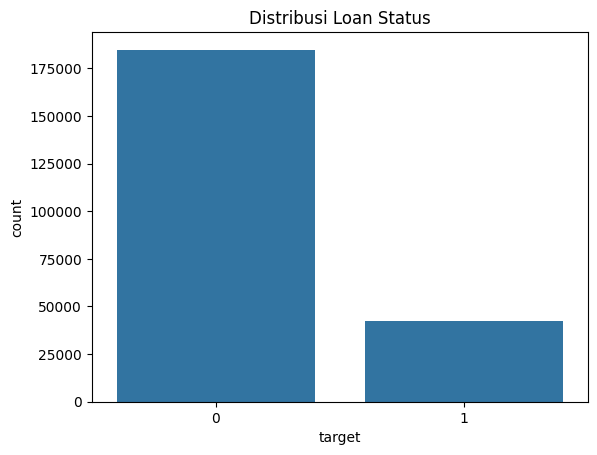

In [15]:
sns.countplot(x='target', data=df)

plt.title('Distribusi Loan Status')
plt.show()

ANALISIS GRADE vs DEFAULT

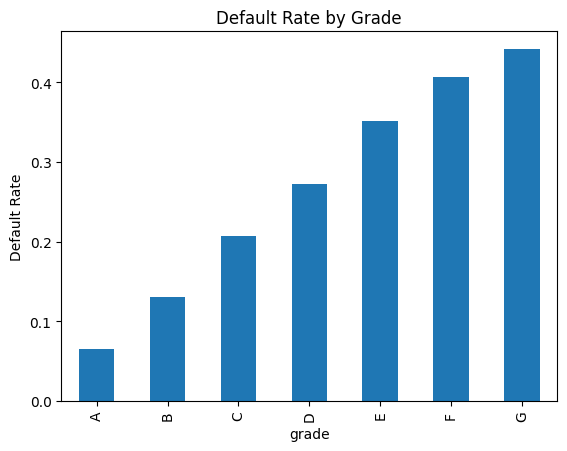

In [16]:
grade_default = df.groupby('grade')['target'].mean().sort_values()

grade_default.plot(kind='bar')

plt.ylabel('Default Rate')
plt.title('Default Rate by Grade')

plt.show()

Analisis Income

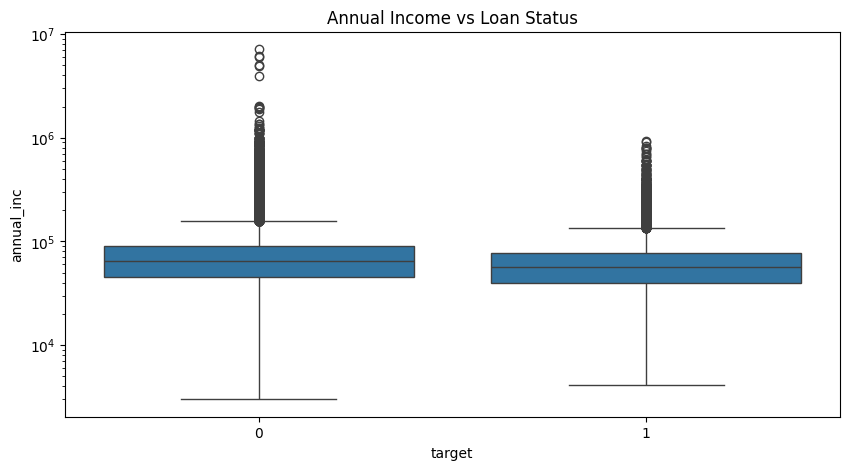

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(x='target', y='annual_inc', data=df)

plt.yscale('log')

plt.title('Annual Income vs Loan Status')

plt.show()

#Correlation

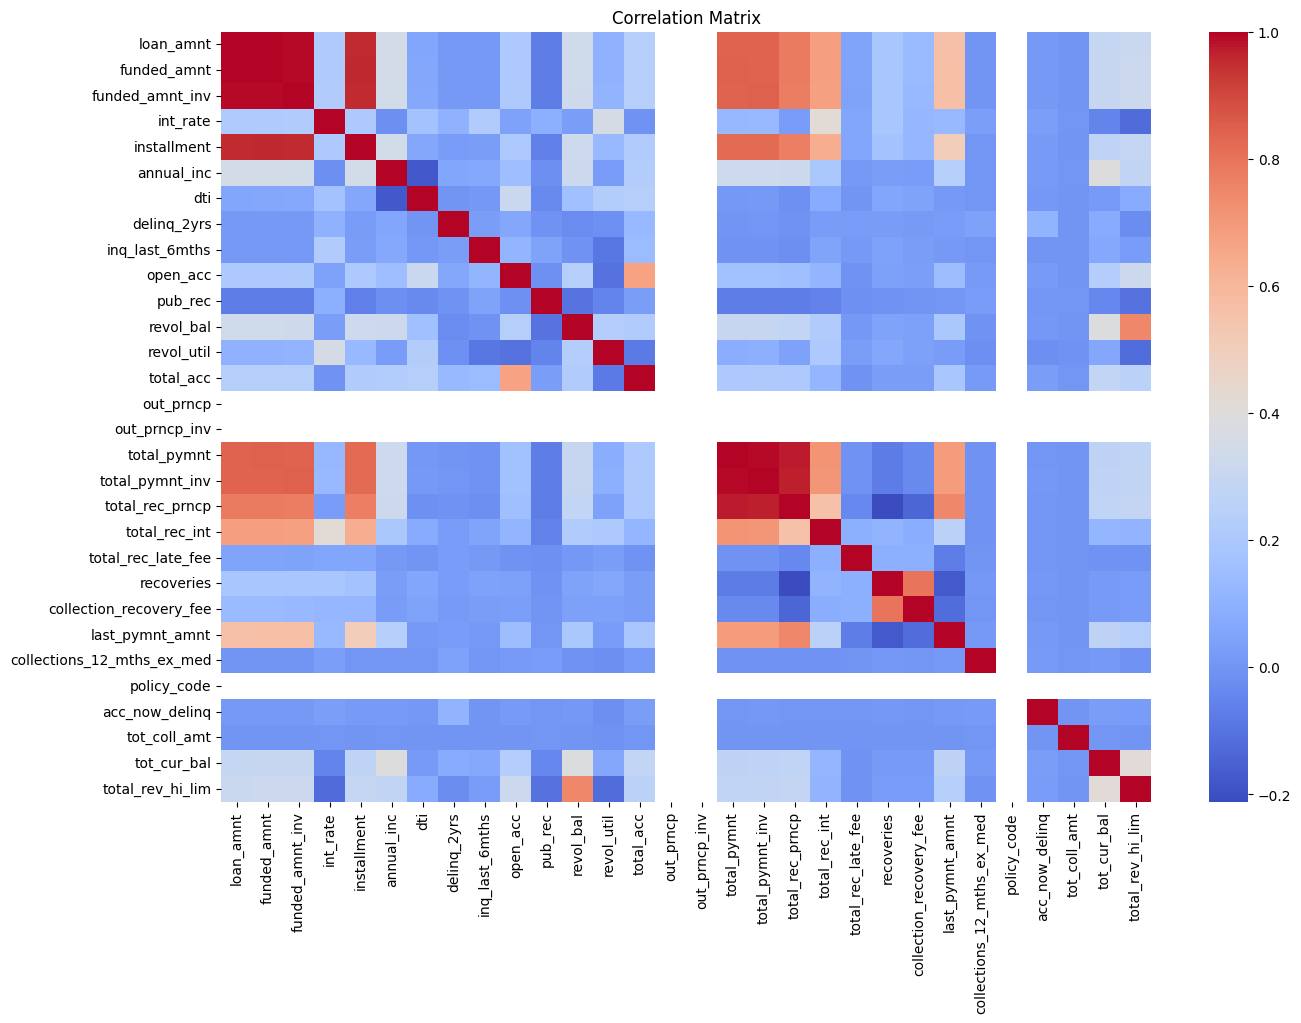

In [18]:
plt.figure(figsize=(15,10))

corr = df[num_cols].corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()

#Feature Selection

In [19]:
selected_features = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'annual_inc',
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'revol_bal',
    'revol_util',
    'total_acc',
    'emp_length'
]

X = df[selected_features]

y = df['target']

In [20]:
#y_prob = log_model.predict_proba(X_test)[:, 1]  # Probabilitas default
#threshold = 0.5  # Ubah threshold di sini

#y_pred_custom = (y_prob > threshold).astype(int)
#auc1 = roc_auc_score(y_test, y_pred_custom)
#print("ROC AUC Score:", auc1)

Linear Regression

              precision    recall  f1-score   support

           0       0.81      0.99      0.89     55422
           1       0.34      0.02      0.04     12743

    accuracy                           0.81     68165
   macro avg       0.58      0.51      0.47     68165
weighted avg       0.73      0.81      0.73     68165



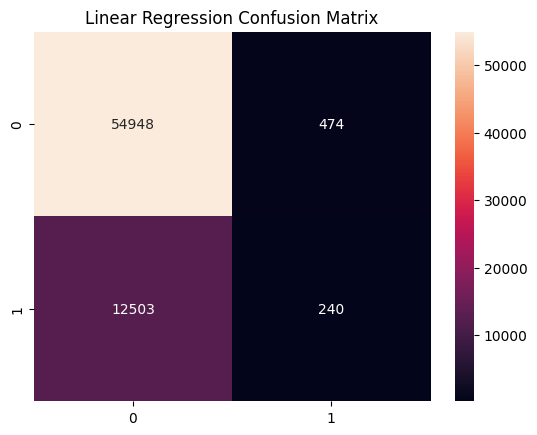

ROC AUC Score: 0.6620507552939185


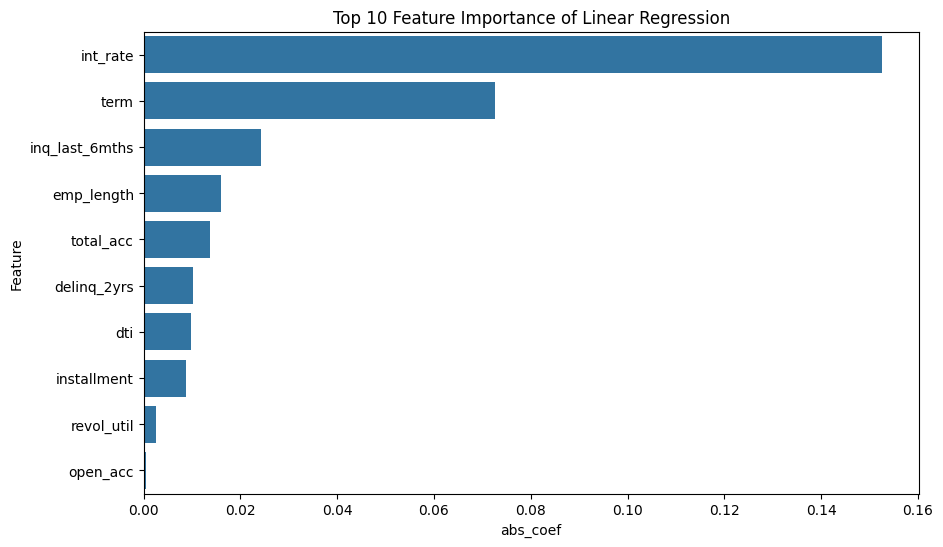

In [21]:
#ENCODING
X = pd.get_dummies(X, drop_first=True)

#TRAIN & TEST
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

#EVALUATION
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Linear Regression Confusion Matrix')
plt.show()

#ROC AUC
y_prob = log_model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", auc)

#FEATURE IMPORTANCE
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

importance['abs_coef'] = abs(importance['Coefficient'])
importance = importance.sort_values(
    by='abs_coef',
    ascending=False
)
importance.head(10)

#VISUALISASI FEATURE IMPORTANCE
plt.figure(figsize=(10,6))
sns.barplot(
    x='abs_coef',
    y='Feature',
    data=importance.head(10)
)
plt.title('Top 10 Feature Importance of Linear Regression')
plt.show()

Random Forest

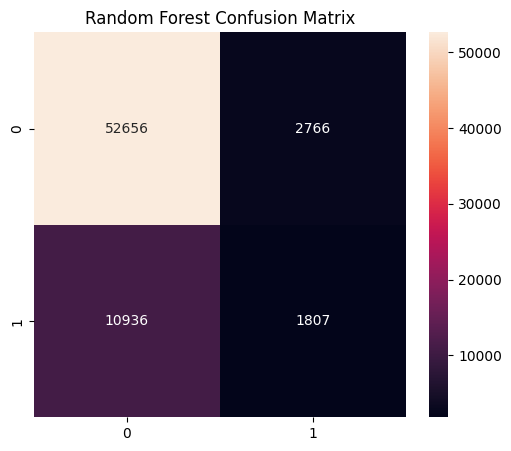

              precision    recall  f1-score   support

           0       0.83      0.95      0.88     55422
           1       0.40      0.14      0.21     12743

    accuracy                           0.80     68165
   macro avg       0.61      0.55      0.55     68165
weighted avg       0.75      0.80      0.76     68165

Random Forest ROC-AUC: 0.6805842670090283
           Feature  Importance
7   inq_last_6mths    0.171051
2         int_rate    0.126731
1             term    0.101421
4       annual_inc    0.070486
5              dti    0.069315
10      revol_util    0.066833
9        revol_bal    0.064091
8         open_acc    0.063203
3      installment    0.059917
11       total_acc    0.056536


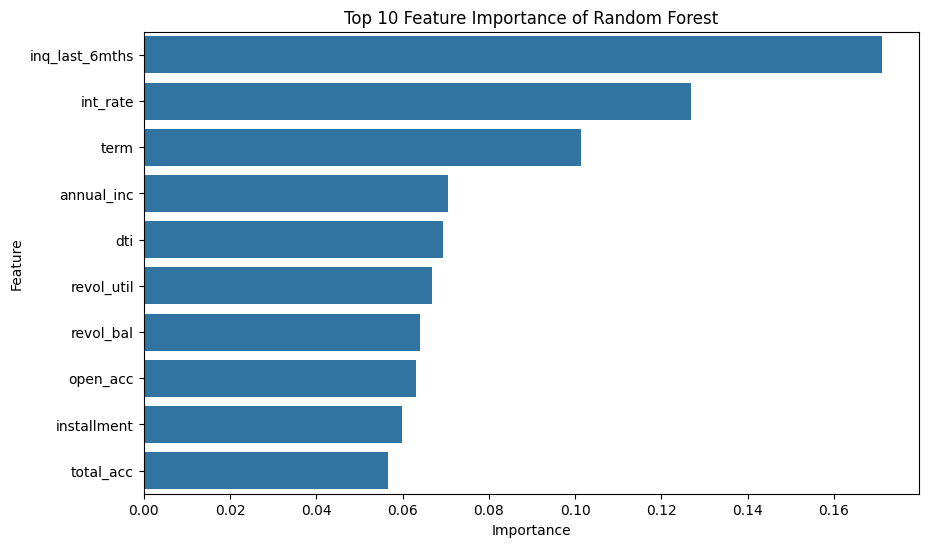

In [22]:
#HANDLING IMBALANCE DATA USING SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

#RANDOM FOREST MODEL
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_smote, y_train_smote)
y_pred = log_model.predict(X_test)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

#TRAIN & TEST
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test)

#EVALUATION
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.show()
print(classification_report(y_test, y_pred_rf))

#ROC AUC
y_prob_rf = rf.predict_proba(X_test)[:,1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC:", auc_rf)

#FEATURE IMPORTANCE
importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
importance_rf = importance_rf.sort_values(
    by='Importance',
    ascending=False
)
print(importance_rf.head(10))

#VISUALISASI FEATURE IMPORTANCE
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_rf.head(10)
)
plt.title('Top 10 Feature Importance of Random Forest')
plt.show()

XGBOOST

              precision    recall  f1-score   support

           0       0.82      0.99      0.90     36948
           1       0.54      0.05      0.08      8495

    accuracy                           0.81     45443
   macro avg       0.68      0.52      0.49     45443
weighted avg       0.77      0.81      0.74     45443



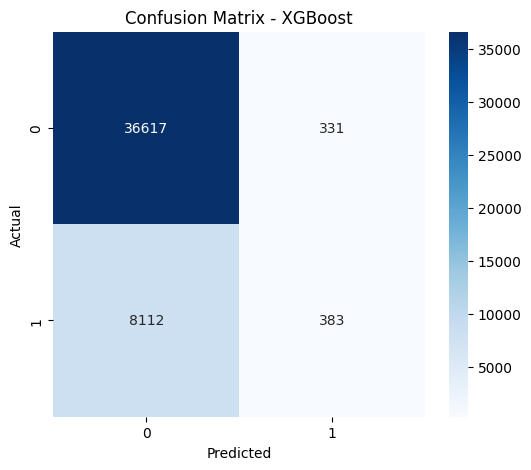

ROC AUC Score: 0.7092656969249307
           Feature  Importance
2         int_rate    0.474361
1             term    0.166280
4       annual_inc    0.069858
5              dti    0.057160
0        loan_amnt    0.034512
12      emp_length    0.034454
7   inq_last_6mths    0.027745
3      installment    0.026883
11       total_acc    0.025054
9        revol_bal    0.023911
10      revol_util    0.021787
8         open_acc    0.019042
6      delinq_2yrs    0.018953


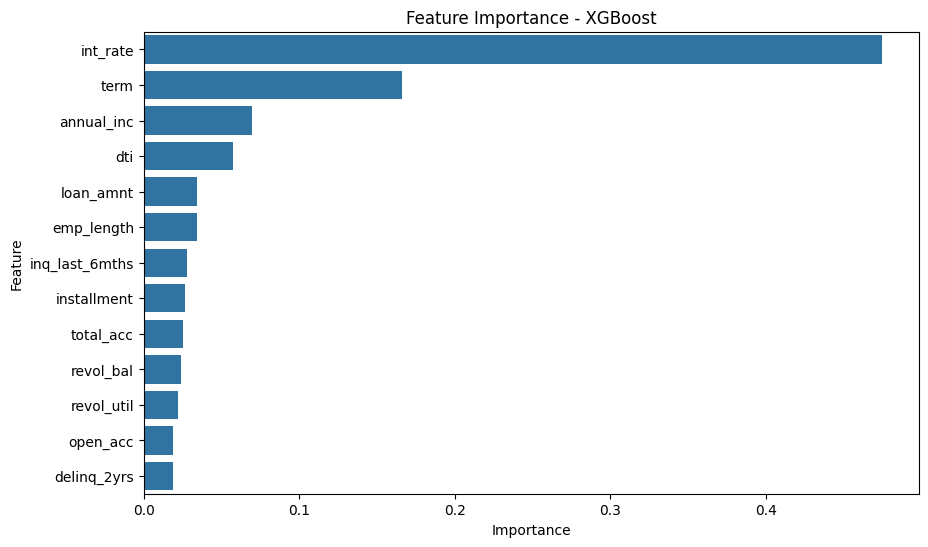

In [25]:
#LOAD DATA
df = pd.read_csv(
    "d:/Syifa_Nalurita_Azahra_VIX_ID_X_Partners-1a756306-b5c0-47a4-838d-6d2806313530 (1)/loan_data_2007_2014.csv"
)

#TARGET VARIABLE
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['target'] = df['loan_status'].apply(
    lambda x: 1 if x == 'Charged Off' else 0
)

#Selected Fitur
selected_features = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'annual_inc',
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'revol_bal',
    'revol_util',
    'total_acc',
    'emp_length'
]
df = df[selected_features + ['target']]

#DATA CLEANING
#term
df['term'] = df['term'].str.replace(' months', '')
df['term'] = df['term'].astype(int)

#int_rate
if df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.replace('%', '')
    df['int_rate'] = df['int_rate'].astype(float)

#revol_util
if df['revol_util'].dtype == 'object':
    df['revol_util'] = df['revol_util'].str.replace('%', '')
    df['revol_util'] = df['revol_util'].astype(float)

#emp_length
df['emp_length'] = df['emp_length'].str.extract('(\d+)')
df['emp_length'] = df['emp_length'].fillna(0)
df['emp_length'] = df['emp_length'].astype(int)

#HANDLE MISSING VALUE
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col].fillna(df[col].median(), inplace=True)

#SPLIT FEATURE & TARGET
X = df.drop(columns='target')
y = df['target']

#TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# XGBOOST MODEL
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

#Train
xgb_model.fit(X_train, y_train)

#PREDICTION
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

#EVALUATION
print(classification_report(y_test, y_pred))

#CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#ROC AUC
auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", auc)

#FEATURE IMPORTANCE
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)
print(importance)

#VISUALISASI FEATURE IMPORTANCE
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title('Feature Importance - XGBoost')
plt.show()